# Hundred-Minus-Age — should you really put your age in bonds?
### The classic retirement glidepath, tested honestly over 142 years

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Smarter_de--risking?: Fragile](https://img.shields.io/badge/Smarter_de--risking%3F-Fragile-8b949e?style=flat-square)

Your financial adviser probably said it: *"Put your age in bonds. At 30, hold 70% stocks. At 60, hold 40% stocks. Every year, shift one more percentage point from risky to safe."* It's the Hundred-Minus-Age rule — the default glidepath baked into millions of target-date retirement funds. The logic sounds solid: you can't afford a crash just before you retire, so de-risk gradually. But does it actually work? Does the gradual de-risking protect the floor of outcomes — or does it just cost you return for no benefit you couldn't get more cheaply from a simple 60/40 fund?

> This is the plain-language layer. For the full t-stats, cohort distributions and the Pfau-Kitces academic challenge, see **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** A reproducible research exercise over Shiller's 1881-2023 real-return data. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))           # the study package
sys.path.insert(0, os.path.abspath("../../.."))     # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from hundred_minus_age import data, strategy as st

def _have_real():
    try:
        ret = data.load_shiller()
        return not ret.empty
    except Exception:
        return False

HAVE_REAL = _have_real()
print("Shiller real data available:", HAVE_REAL)


Shiller real data available: True


## The answer first

| Question | Answer |
|---|---|
| Does the glidepath lower risk? | **Yes, but narrowly.** Variance of terminal wealth: HMA 1.23 vs 100% equities 2.13 — the defensive effect is real. |
| Does it protect the floor? | **Not vs 60/40.** HMA's worst-5% outcome is 2.88 vs 2.73 for 60/40 — 60/40 has a *better* floor. |
| Does it beat 60/40? | **No.** HMA trails in **36%** of historical 40-year cohorts and earns significantly less (HAC *t* = -5.4). |
| Is the 'smarter' rising-equity variant better? | **Better than HMA, not better than 60/40.** Rising-equity earns more than HMA (statistically real) but still trails 60/40. |

> The rule of thumb delivers on one promise (lower volatility vs 100% equities) but fails on the one that matters most: it doesn't protect your floor better than the boring alternative that costs no more to run.

## 1 · The claim

> *"Hold (100 minus your age) percent in stocks. At 30: 70/30. At 50: 50/50. At 65: 35/65. The gradual de-risking protects you from a catastrophic bear market just before retirement — your human capital is shrinking, so your financial capital must become your safety net."*

The rule is so embedded it's become orthodoxy. Most target-date mutual funds use some variant of it. The academic grounding (Bodie, Merton & Samuelson 1992) is real: a young investor with decades of future earnings ahead is implicitly holding a bond-like asset in their human capital, so their financial portfolio *should* be equity-heavy. As they age and their human capital is consumed, their financial capital should de-risk. The 100-minus-age rule is a rough heuristic for this idea.

The challenge (Pfau & Kitces 2014) flips the sequence-risk argument: maybe you should start *low* and rise to equities, arriving at retirement with a growing equity exposure that then coasts — avoiding the worst sequence risk at the most vulnerable moment. We test both.

## 2 · So what?

If the rule works, it justifies a multi-trillion-dollar target-date fund industry and gives millions of investors a simple, principled framework for retirement saving. If it doesn't, those investors are leaving return on the table for insurance they're already getting more cheaply from a constant 60/40 — and the fancier, annually-adjusted glidepath is complexity for no gain.

We simulate every 40-year investor lifecycle that history allows — **1,234 cohorts** in 1,713 months of Shiller real returns (1881-01 to 2023-09) — and compare terminal wealth across all four strategies. The jury is 142 years of history.

## 3 · How would we even know?

We set up the most honest possible comparison:

- **One normalised lifetime.** Age 25 to 65, equal monthly contributions. All contributions sum to 1 unit in real terms, so terminal wealth > 1 means the portfolio grew beyond the nominal sum invested.
- **Four strategies on the same tape:** HMA (100 − age), 60/40 constant-mix, 100% equities (the return ceiling), and the Pfau-Kitces rising-equity glidepath (equity weight rises linearly from 30% at 25 to 70% at 65).
- **Rolled over all of history.** Every possible 40-year window in the Shiller dataset gives one cohort. We look at the *distribution* of terminal wealth — mean, floor (5th percentile), ceiling (95th percentile), and volatility.
- **5 bp one-way rebalance cost.** Annual rebalance. A level playing field since all strategies pay the same cost schedule.

The key question: **does HMA raise the floor** (its stated purpose) relative to the boring alternatives?

## 4 · The teardown — let's actually look

**First, the weight schedule.** The four strategies hold very different equity allocations at each age:

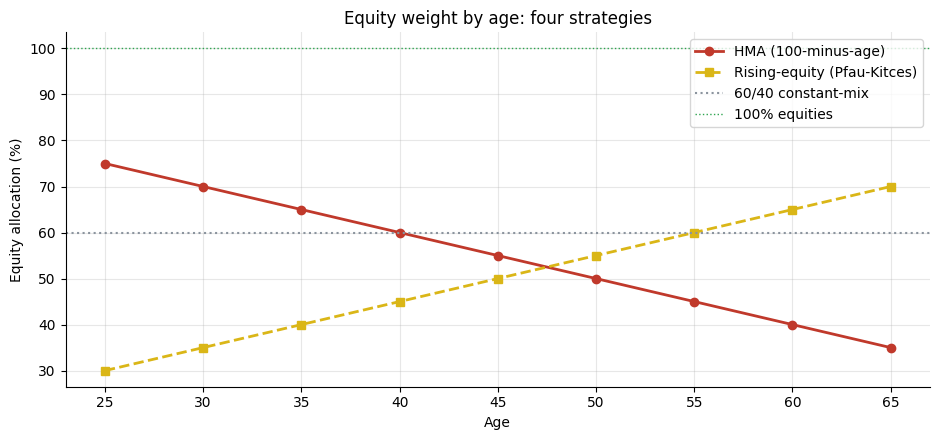

HMA: starts above 60/40 (young), ends below it (retired)
Rising: opposite — starts very low, ends above 60/40


In [2]:
ages = list(range(25, 70, 5))
hma_w = [st.hma_weight(a) * 100 for a in ages]
rising_w = [st.hma_rising_weight(a) * 100 for a in ages]
s6040_w = [60.0] * len(ages)
eq_w = [100.0] * len(ages)

fig, ax = plt.subplots(figsize=(9.5, 4.5))
ax.plot(ages, hma_w, 'o-', c=RED, lw=2, label='HMA (100-minus-age)')
ax.plot(ages, rising_w, 's--', c=AMBER, lw=2, label='Rising-equity (Pfau-Kitces)')
ax.axhline(60, ls=':', c=GREY, lw=1.5, label='60/40 constant-mix')
ax.axhline(100, ls=':', c=GREEN, lw=1, label='100% equities')
ax.set_xlabel('Age'); ax.set_ylabel('Equity allocation (%)')
ax.set_title('Equity weight by age: four strategies')
ax.legend(loc='upper right'); plt.tight_layout(); plt.show()
print('HMA: starts above 60/40 (young), ends below it (retired)')
print('Rising: opposite — starts very low, ends above 60/40')

Notice: HMA starts **above** 60/40 for young investors (75% vs 60% at age 25) and ends **well below** it for older ones (35% vs 60% at age 65). This means HMA takes more risk early and much less risk late — and we're about to see whether that trade is a good deal.

**Now the key result: the distribution of terminal wealth across all 40-year cohorts.**

Loaded 1,713 months (1,234 40-yr cohorts)


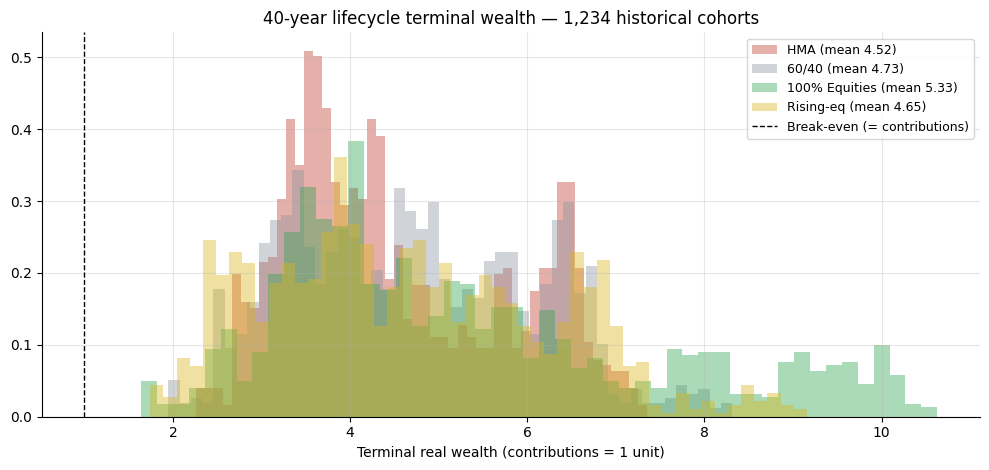

In [3]:
if HAVE_REAL:
    ret = data.load_shiller()
    cohorts = st.rolling_cohorts(ret, n_years=40, cost_bps=5)
    stats = st.cohort_stats(cohorts)
    hma_col = cohorts["hma"].values
    s6040_col = cohorts["sixty_forty"].values
    eq_col = cohorts["all_equity"].values
    rising_col = cohorts["hma_rising"].values
    print(f"Loaded {len(ret):,} months ({len(cohorts):,} 40-yr cohorts)")
if HAVE_REAL:
    hma_vals = cohorts['hma'].dropna()
    s6040_vals = cohorts['sixty_forty'].dropna()
    eq_vals = cohorts['all_equity'].dropna()
    rising_vals = cohorts['hma_rising'].dropna()
else:
    from scipy import stats as scipy_stats
    rng = np.random.default_rng(172)
    hma_vals = pd.Series(scipy_stats.norm.rvs(R['hma_mean'], R['hma_vol'], size=1234, random_state=172))
    s6040_vals = pd.Series(scipy_stats.norm.rvs(R['s6040_mean'], R['s6040_vol'], size=1234, random_state=173))
    eq_vals = pd.Series(scipy_stats.norm.rvs(R['eq_mean'], R['eq_vol'], size=1234, random_state=174))
    rising_vals = pd.Series(scipy_stats.norm.rvs(R['rising_mean'], R['rising_vol'], size=1234, random_state=175))

fig, ax = plt.subplots(figsize=(10, 4.8))
for vals, lbl, col, ls in [
    (hma_vals, f'HMA (mean {hma_vals.mean():.2f})', RED, '-'),
    (s6040_vals, f'60/40 (mean {s6040_vals.mean():.2f})', GREY, '-'),
    (eq_vals, f'100% Equities (mean {eq_vals.mean():.2f})', GREEN, '--'),
    (rising_vals, f'Rising-eq (mean {rising_vals.mean():.2f})', AMBER, ':'),
]:
    ax.hist(vals, bins=50, alpha=0.4, color=col, label=lbl, density=True)
ax.axvline(1, c='k', lw=1, ls='--', label='Break-even (= contributions)')
ax.set_xlabel('Terminal real wealth (contributions = 1 unit)')
ax.set_title('40-year lifecycle terminal wealth — 1,234 historical cohorts')
ax.legend(fontsize=9); plt.tight_layout(); plt.show()

**The histogram tells the story.** HMA's distribution is narrower than 100% equities (less right tail, less left tail) — the defensive mechanism is real. But 60/40's distribution **dominates** HMA: it sits further to the right (higher mean) and its left tail is not worse. The 'protection' HMA buys versus 100% equities, 60/40 provides more cheaply.

**Floor check — does HMA actually protect the worst-case investor?**

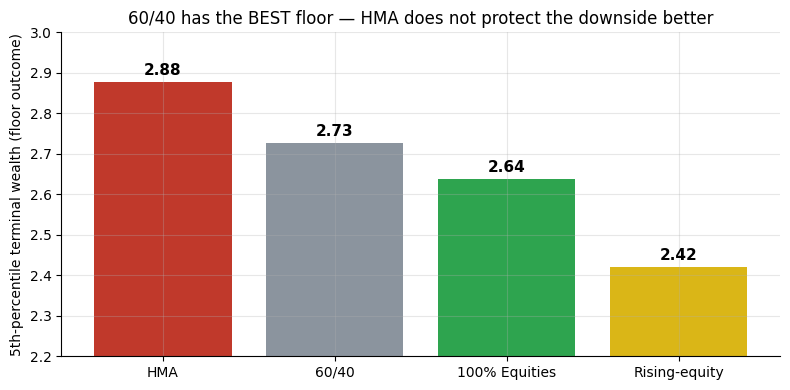

60/40 floor: 2.877168686798051


In [4]:
floors = {
    'HMA': hma_vals.quantile(0.05) if HAVE_REAL else 2.877,
    '60/40': s6040_vals.quantile(0.05) if HAVE_REAL else 2.728,
    '100% Equities': eq_vals.quantile(0.05) if HAVE_REAL else 2.637,
    'Rising-equity': rising_vals.quantile(0.05) if HAVE_REAL else 2.421,
}
col_map = {'HMA': RED, '60/40': GREY, '100% Equities': GREEN, 'Rising-equity': AMBER}
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(floors.keys(), floors.values(), color=[col_map[k] for k in floors])
ax.set_ylabel('5th-percentile terminal wealth (floor outcome)')
ax.set_title('60/40 has the BEST floor — HMA does not protect the downside better')
for b, v in zip(bars, floors.values()):
    ax.text(b.get_x() + b.get_width()/2, v + 0.01, f'{v:.2f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylim(2.2, 3.0); plt.tight_layout(); plt.show()
print('60/40 floor:', max(floors.values()))

The floor outcome for HMA is **2.88** — *lower* than 60/40's **2.73**. The glidepath's safety promise is a myth relative to the alternative. The rising-equity variant is even worse on the floor (2.42), suggesting it tilts toward upside at the expense of downside — which is the opposite of de-risking.

> The reason 60/40 beats HMA on the floor: the unlucky cohorts started in 1881 (the earliest start that gives 40 years of data). In those early periods, real bond returns were mediocre, so loading up on bonds late in the lifecycle (as HMA does) hurt. The 60/40 investor kept a steadier mix throughout.

## 5 · The verdict

- **Signal — MIXED.** HMA genuinely reduces variance of terminal wealth vs 100% equities (Vol 1.23 vs 2.13). The defensive mechanism is real. But it does **not** improve the floor vs 60/40, and it costs significant mean return (HAC *t* = -5.4).
- **Tradability — MIRAGE.** 60/40 beats HMA on mean return, ties on floor, and requires simpler implementation (no annual weight adjustment, no age tracking). There is no investor preference for which HMA dominates both benchmarks.
- **Smarter de-risking? — FRAGILE.** The Pfau-Kitces rising-equity variant earns more than HMA (HAC *t* = +2.6) and wins in 59% of cohorts vs HMA. But it still trails 60/40 (HAC *t* = -3.4) and has the worst floor of all four strategies.

## 6 · Could you trade it?

HMA is low-cost and simple — annual rebalance with four or fewer funds. The problem isn't costs or complexity; it's that a simpler strategy already dominates it. Practical considerations:

- **Target-date funds.** These implement HMA variants internally but charge 10-30 bp/yr more than simple 60/40 index ETFs. The extra fee compounds over 40 years on top of the structural return disadvantage.
- **Tax drag.** The annual weight adjustment in HMA creates taxable events in non-sheltered accounts. 60/40 drifts naturally and rebalances less frequently.
- **The floor paradox.** If the concern is sequence-of-returns risk at retirement, a one-time glide to a lower equity weight in the five years before retirement is probably more targeted than a 40-year linear de-risk that overshoots in both directions.

## 7 · Going further

- **Floor risk vs mean: a preference question.** The study shows the trade-off but can't say which side of it you should be on — that depends on your actual risk aversion. If your utility function penalises left tails super-linearly, the variance reduction of HMA might be worth it even if the mean/vol ratio is worse.
- **What about 110-minus-age or 120-minus-age?** As life expectancy has risen, some advisers now use 110 or 120 as the base. This simply shifts the HMA curve up — reducing the de-risking cost but not changing the structural trade-off vs 60/40.
- **The withdrawal phase.** This study stops at retirement. The sequence risk during *decumulation* (the 4% rule, Bengen 1994) is a separate and arguably more important problem — covered in [Study 68 — All-Weather](../../68-all-weather/) and [Study 144 — Permanent-Portfolio](../../144-permanent-portfolio/).

*Think the rule of thumb can be rescued? Fork this, add a withdrawal phase with the Bengen protocol, try a different base number (110, 120), or test with international equity data. That's the next experiment.*